In [1]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print("✅ Libraries loaded")

✅ Libraries loaded


In [3]:
df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nFirst 3 rows:")
df.head(3)

Shape: (9994, 21)

Columns:
 ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data types:
 Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

First 3 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [4]:
# Fix date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

# Check for nulls
print("Null values:\n", df.isnull().sum())

# Check for duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# Drop duplicates if any
df.drop_duplicates(inplace=True)

# Add time columns we'll need later
df['Year']       = df['Order Date'].dt.year
df['Month']      = df['Order Date'].dt.month
df['YearMonth']  = df['Order Date'].dt.to_period('M')

print("\n✅ Data cleaned. Shape:", df.shape)

Null values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate rows: 0

✅ Data cleaned. Shape: (9994, 24)


In [5]:
print("=== BASIC STATS ===")
print(f"Date range   : {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")
print(f"Total sales  : ${df['Sales'].sum():,.0f}")
print(f"Total profit : ${df['Profit'].sum():,.0f}")
print(f"Unique orders: {df['Order ID'].nunique()}")
print(f"Customers    : {df['Customer ID'].nunique()}")
print(f"Products     : {df['Product ID'].nunique()}")
print(f"\nCategories   : {df['Category'].unique()}")
print(f"Regions      : {df['Region'].unique()}")
print(f"Segments     : {df['Segment'].unique()}")

=== BASIC STATS ===
Date range   : 2014-01-03 → 2017-12-30
Total sales  : $2,297,201
Total profit : $286,397
Unique orders: 5009
Customers    : 793
Products     : 1862

Categories   : ['Furniture' 'Office Supplies' 'Technology']
Regions      : ['South' 'West' 'Central' 'East']
Segments     : ['Consumer' 'Corporate' 'Home Office']


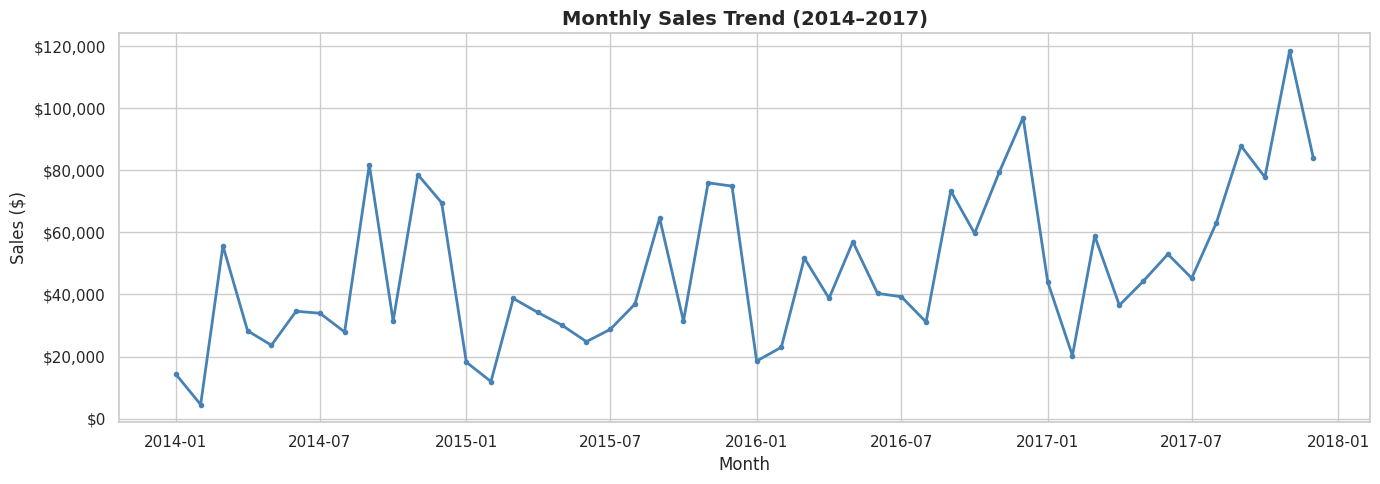

✅ Saved: monthly_sales_trend.png


In [6]:
monthly_sales = df.groupby('YearMonth')['Sales'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].dt.to_timestamp()

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['YearMonth'], monthly_sales['Sales'],
         color='steelblue', linewidth=2, marker='o', markersize=3)
plt.title('Monthly Sales Trend (2014–2017)')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=150)
plt.show()
print("✅ Saved: monthly_sales_trend.png")

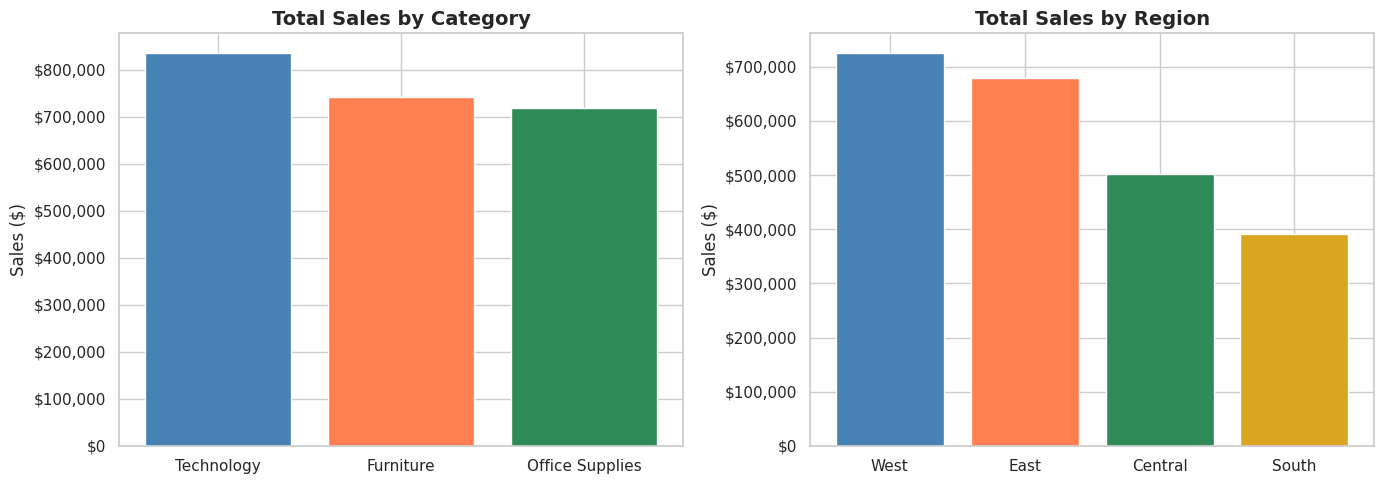

✅ Saved: sales_by_category_region.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By Category
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
axes[0].bar(cat_sales.index, cat_sales.values, color=['steelblue','coral','seagreen'])
axes[0].set_title('Total Sales by Category')
axes[0].set_ylabel('Sales ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# By Region
reg_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
axes[1].bar(reg_sales.index, reg_sales.values, color=['steelblue','coral','seagreen','goldenrod'])
axes[1].set_title('Total Sales by Region')
axes[1].set_ylabel('Sales ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('sales_by_category_region.png', dpi=150)
plt.show()
print("✅ Saved: sales_by_category_region.png")

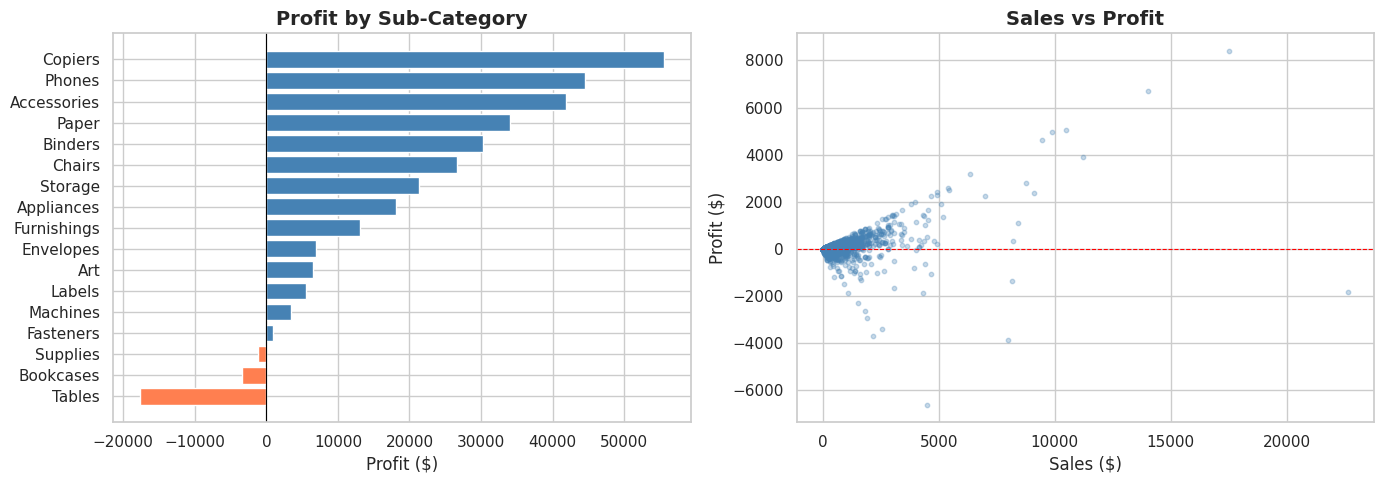

✅ Saved: profit_analysis.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Profit by Sub-Category
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['coral' if v < 0 else 'steelblue' for v in sub_profit.values]
axes[0].barh(sub_profit.index, sub_profit.values, color=colors)
axes[0].set_title('Profit by Sub-Category')
axes[0].set_xlabel('Profit ($)')
axes[0].axvline(0, color='black', linewidth=0.8)

# Sales vs Profit scatter
axes[1].scatter(df['Sales'], df['Profit'], alpha=0.3, color='steelblue', s=10)
axes[1].set_title('Sales vs Profit')
axes[1].set_xlabel('Sales ($)')
axes[1].set_ylabel('Profit ($)')
axes[1].axhline(0, color='red', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('profit_analysis.png', dpi=150)
plt.show()
print("✅ Saved: profit_analysis.png")

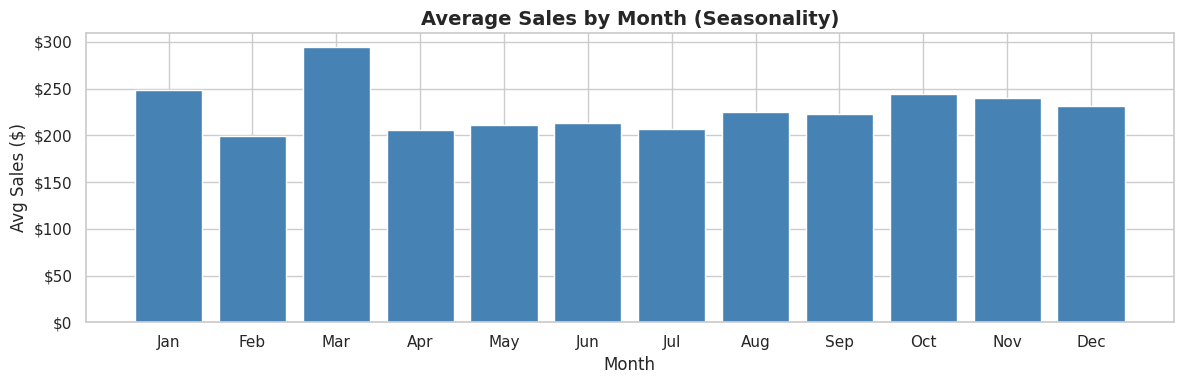

✅ Saved: seasonality.png


In [9]:
monthly_avg = df.groupby('Month')['Sales'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12, 4))
plt.bar(month_names, monthly_avg.values, color='steelblue')
plt.title('Average Sales by Month (Seasonality)')
plt.xlabel('Month')
plt.ylabel('Avg Sales ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('seasonality.png', dpi=150)
plt.show()
print("✅ Saved: seasonality.png")